Raw shape: (6378, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72



Numeric-only shape: (6378, 7)
All columns numeric? True


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
0,23,84,7,73,0,3,67
1,19,64,8,59,2,4,61
2,24,98,7,91,2,4,74
3,29,89,8,98,1,4,71
4,19,92,6,65,3,4,70
5,19,88,8,89,3,3,71
6,29,84,7,68,1,2,67
7,25,78,6,50,1,2,66
8,17,94,6,80,0,1,69
9,23,98,8,71,0,5,72



Saved numeric dataset (no label) to: C:\Users\User\Machine\Jupyter file\dataset1_kmeans_clean.csv

Standardization check:
Mean (first 5): [-0.  0. -0.  0.  0.]
Std  (first 5): [1. 1. 1. 1. 1.]

--- PCA (3 components) ---
Covariance matrix shape: (7, 7)
Variance per feature (first 10): [1.000157 1.000157 1.000157 1.000157 1.000157 1.000157 1.000157]

Eigenvalues (PC1..PC3): [1.766798 1.042698 1.020515]
Explained variance ratio (PC1..PC3): [0.25236  0.148933 0.145765]
Info saved in PC3 (PC1+PC2+PC3): 54.71%

Eigenvectors shape (3 x features): (3, 7)


,PC1,PC2,PC3
Hours_Studied,0.409972,0.543087,0.259446
Attendance,0.532218,-0.447756,-0.217189
Sleep_Hours,-0.029490,0.205994,0.434133
Previous_Scores,0.158729,0.517948,-0.334635
Tutoring_Sessions,0.146006,-0.439770,0.382713


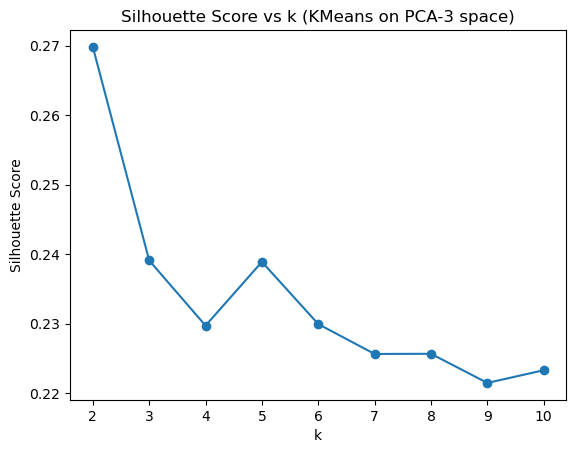


Top 3 k values by silhouette:
  k=2, silhouette=0.2698
  k=3, silhouette=0.2391
  k=5, silhouette=0.2389


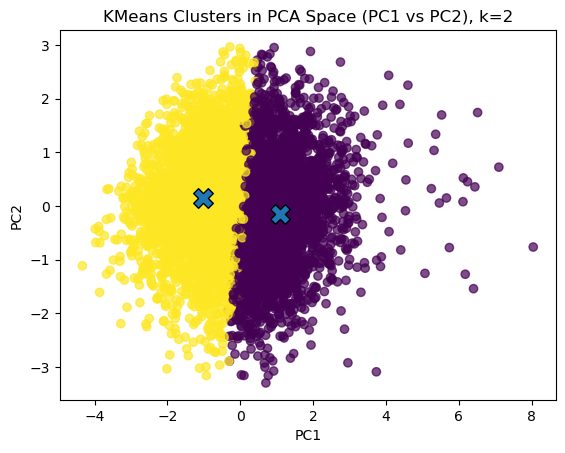

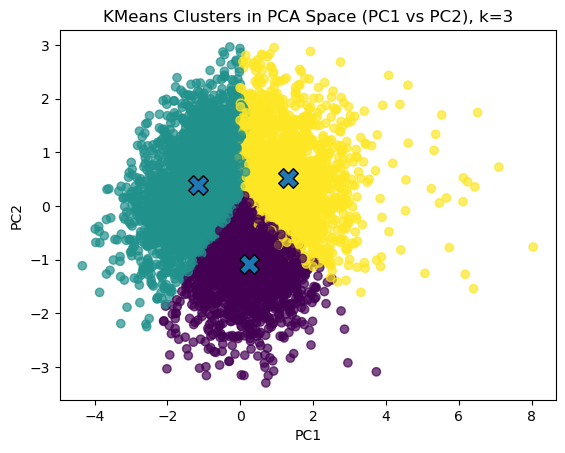

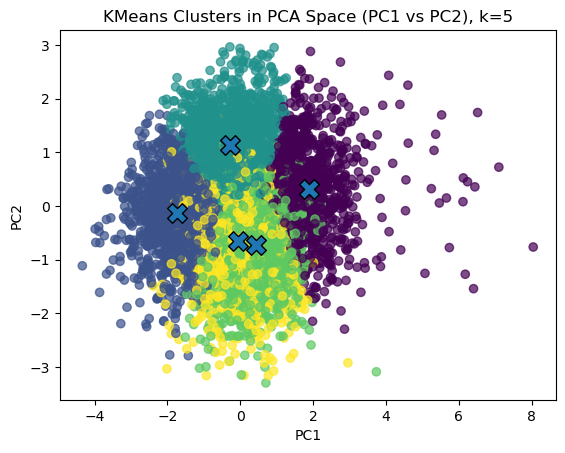


Discussion prompt:
- Compare how cluster separation and silhouette scores change across the three k values.
- Higher silhouette usually indicates better separation; visually check if clusters overlap or split unnaturally.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# Choose labeled dataset

path = (r"C:\Users\User\Machine\Jupyter file\dataset1_raw.csv")
raw_df = pd.read_csv(path).copy()
raw_df = raw_df.dropna()

# Put label column name(s) here (the dataset is "labeled" because it has one)
#LABEL_COLS = []  # e.g., ["quality_label"] or ["Class"]

print("Raw shape:", raw_df.shape)
display(raw_df.head(10))

# Remove label + ensure everything quantitative

df_work = raw_df.copy()

# Drop known label columns if present
label_present = [c for c in LABEL_COLS if c in df_work.columns]
if label_present:
    df_work = df_work.drop(columns=label_present)
    print("Dropped label column(s):", label_present)

# Drop non-quantitative columns
DROP_COLS = ["id", "gender", "occupation_type"]  # adjust if needed
drop_present = [c for c in DROP_COLS if c in df_work.columns]
df_work = df_work.drop(columns=drop_present)

# Keep ONLY numeric after drops 
df_numeric = df_work.select_dtypes(include=[np.number]).copy()

print("\nNumeric-only shape:", df_numeric.shape)
print("All columns numeric?", all(np.issubdtype(dt, np.number) for dt in df_numeric.dtypes))
display(df_numeric.head(10))

# Save new dataset

SAVED_DATASET_PATH = (r"C:\Users\User\Machine\Jupyter file\dataset1_kmeans_clean.csv")
df_numeric.to_csv(SAVED_DATASET_PATH, index=False)
print("\nSaved numeric dataset (no label) to:", SAVED_DATASET_PATH)

# Normalize data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

# quick check
print("\nStandardization check:")
print("Mean (first 5):", np.round(X_scaled.mean(axis=0)[:5], 6))
print("Std  (first 5):", np.round(X_scaled.std(axis=0, ddof=0)[:5], 6))

# Perform PCA with n=3 components 

pca3 = PCA(n_components=3, random_state=42)
Z3 = pca3.fit_transform(X_scaled)

# Covariance matrix of standardized data (features x features)
cov_matrix = np.cov(X_scaled, rowvar=False)

# Variance of each standardized feature (diagonal of covariance)
variance_per_feature = np.diag(cov_matrix)

# Eigenvalues/eigenvectors from sklearn PCA:
# explained_variance_ = eigenvalues of covariance matrix along PCs
eigenvalues = pca3.explained_variance_
eigenvectors = pca3.components_  # rows = PC directions
explained_ratio = pca3.explained_variance_ratio_

info_saved_pc3 = explained_ratio.sum() * 100

print("\n--- PCA (3 components) ---")
print("Covariance matrix shape:", cov_matrix.shape)
print("Variance per feature (first 10):", np.round(variance_per_feature[:10], 6))
print("\nEigenvalues (PC1..PC3):", np.round(eigenvalues, 6))
print("Explained variance ratio (PC1..PC3):", np.round(explained_ratio, 6))
print(f"Info saved in PC3 (PC1+PC2+PC3): {info_saved_pc3:.2f}%")
print("\nEigenvectors shape (3 x features):", eigenvectors.shape)

# Optional: nice loadings table
loadings3 = pd.DataFrame(
    eigenvectors.T,
    index=df_numeric.columns,
    columns=["PC1", "PC2", "PC3"]
)
display(loadings3.head())

# Silhouette method to find 3 optimal values of K

def silhouette_scan(X, k_min=2, k_max=10, random_state=42):
    ks = list(range(k_min, k_max + 1))
    sils = []
    for k in ks:
        km = KMeans(n_clusters=k, n_init=20, random_state=random_state)
        labels = km.fit_predict(X)
        sils.append(silhouette_score(X, labels))
    return ks, np.array(sils)

k_min, k_max = 2, 10
ks, sils = silhouette_scan(Z3, k_min, k_max)

plt.figure()
plt.plot(ks, sils, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k (KMeans on PCA-3 space)")
plt.show()

# Get top 3 K values by silhouette score
top3_idx = np.argsort(sils)[::-1][:3]
top3_ks = [ks[i] for i in top3_idx]
top3_scores = [sils[i] for i in top3_idx]

print("\nTop 3 k values by silhouette:")
for k, s in zip(top3_ks, top3_scores):
    print(f"  k={k}, silhouette={s:.4f}")

# Plot and include centroids (3 plots for 3 different K values)

pca_plot_df = pd.DataFrame(Z3, columns=["PC1", "PC2", "PC3"])

for k in top3_ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(Z3)
    centroids = km.cluster_centers_  # in PCA space

    # 2D plot in PCA space (PC1 vs PC2) with centroids
    plt.figure()
    plt.scatter(pca_plot_df["PC1"], pca_plot_df["PC2"], c=labels, alpha=0.7)
    plt.scatter(centroids[:, 0], centroids[:, 1], marker="X", s=200, edgecolors="k")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"KMeans Clusters in PCA Space (PC1 vs PC2), k={k}")
    plt.show()
